In [1]:

# ==========================================
# 1. CONFIGURACIÓN Y MONTAJE DE DRIVE
# ==========================================
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, Bidirectional,
    Layer, Concatenate, Add, Flatten, Permute, Multiply,
    RepeatVector, Lambda
)
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K

# Fijar seeds
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Estilos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ------------------------------------------
# Rutas
# ------------------------------------------
DATA_PATH = "/content/drive/MyDrive/Curso Especializacion/Proyecto/master_dataset_colab.csv"
RESULTS_DIR = "/content/drive/MyDrive/Curso Especializacion/Proyecto/results"
DAY6_RESULTS = os.path.join(RESULTS_DIR, "day6_hyperparams_results.csv")
os.makedirs(RESULTS_DIR, exist_ok=True)

RESULTS_CSV = os.path.join(RESULTS_DIR, "day7_architecture_results.csv")
BEST_MODEL_PATH = os.path.join(RESULTS_DIR, "best_model_day7.keras")

In [4]:
# ==========================================
# 2. CARGAR MEJOR CONFIGURACIÓN DEL DÍA 6
# ==========================================
print("\n📋 Cargando resultados del Día 6...")
if os.path.exists(DAY6_RESULTS):
    day6_df = pd.read_csv(DAY6_RESULTS)
    best_config = day6_df.dropna(subset=['test_mae_real']).nsmallest(1, 'test_mae_real').iloc[0]
    BEST_LR = best_config['learning_rate']
    BEST_BATCH = int(best_config['batch_size'])
    BEST_OPTIMIZER = best_config['optimizer']
    BEST_DROPOUT = best_config['dropout']
    BEST_SEQ = int(best_config['seq_length'])
    print(f"  Mejor config Día 6: lr={BEST_LR}, batch={BEST_BATCH}, "
          f"opt={BEST_OPTIMIZER}, dropout={BEST_DROPOUT}, seq={BEST_SEQ}")
    print(f"  MAE baseline: {best_config['test_mae_real']:.4f} µg/m³")
else:
    print("  ⚠️ No se encontraron resultados del Día 6. Usando defaults.")
    BEST_LR = 0.001
    BEST_BATCH = 64
    BEST_OPTIMIZER = 'adam'
    BEST_DROPOUT = 0.2
    BEST_SEQ = 24


📋 Cargando resultados del Día 6...
  Mejor config Día 6: lr=0.001, batch=64, opt=rmsprop, dropout=0.2, seq=24
  MAE baseline: 2.6781 µg/m³


In [5]:
# ==========================================
# 3. CARGA Y PREPROCESAMIENTO DE DATOS
# ==========================================
print("\n📂 Cargando datos...")
df = pd.read_csv(DATA_PATH)
print(f"  Shape original: {df.shape}")

# ----- Feature Engineering: Encodings Cíclicos -----
# Nota: Las columnas hour_sin, hour_cos, etc. ya podrían existir desde el notebook 05.
# Si no existen, las creamos aquí.
if 'hour_sin' not in df.columns:
    print("  🔧 Creando encodings cíclicos...")
    # Necesitamos la columna 'hour' y 'day_of_week' si existen
    if 'hour' in df.columns:
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    if 'day_of_week' in df.columns:
        df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    print(f"  Shape con features cíclicos: {df.shape}")
else:
    print("  ✅ Encodings cíclicos ya presentes en el dataset")


📂 Cargando datos...
  Shape original: (195183, 22)
  🔧 Creando encodings cíclicos...
  Shape con features cíclicos: (195183, 22)


In [6]:
df['fecha'] = pd.to_datetime(df['fecha'])
# Eliminar la columna 'fecha' antes de pasar al modelo, ya que ya tenemos características de tiempo numéricas
df = df.drop(columns=['fecha'])
print(f"Columnas después de eliminar 'fecha': {list(df.columns)}")
print(f"Tipos de datos actualizados:\n{df.dtypes}")

Columnas después de eliminar 'fecha': ['pm25', 'no2', 'o3', 'temperatura', 'velocidad_viento', 'precipitacion', 'humedad_relativa', 'hora_del_dia', 'dia_de_la_semana', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_rolling_6h', 'station_name', 'station_Francia', 'station_Molí del Sol', 'station_Pista de Silla', 'station_Puerto Moll Trans. Ponent', 'station_Puerto Valencia', 'station_Puerto llit antic Túria', 'station_Universidad Politécnica']
Tipos de datos actualizados:
pm25                                 float64
no2                                  float64
o3                                   float64
temperatura                          float64
velocidad_viento                     float64
precipitacion                        float64
humedad_relativa                     float64
hora_del_dia                           int64
dia_de_la_semana                       int64
pm25_lag1                            float64
pm25_lag2                            float64
pm25_lag3                      

In [7]:
# ==========================================
# 4. FUNCIONES AUXILIARES
# ==========================================
def create_sequences_by_station(data, seq_length, target_col_name='pm25', group_col='station_name'):
    """Genera secuencias temporales agrupadas por estación."""
    xs, ys = [], []
    for station, group in data.groupby(group_col):
        group_no_station = group.drop(columns=[group_col])
        group_values = group_no_station.values
        target_values = group[target_col_name].values
        for i in range(len(group_values) - seq_length):
            xs.append(group_values[i:(i + seq_length), :])
            ys.append(target_values[i + seq_length])
    return np.array(xs), np.array(ys)


def prepare_data(df, seq_length, seed=42):
    """Normaliza, crea secuencias y divide en train/val/test."""
    scaler = MinMaxScaler()
    cols_to_scale = [c for c in df.columns if c != 'station_name']
    df_scaled = df.copy()
    df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    pm25_col_idx = cols_to_scale.index('pm25')
    n_features = len(cols_to_scale)

    X, y = create_sequences_by_station(df_scaled, seq_length)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=seed)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=seed)

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler': scaler, 'pm25_col_idx': pm25_col_idx,
        'n_features': n_features, 'n_input_features': X.shape[2]
    }


def inverse_pm25(values, scaler, pm25_col_idx, n_features):
    """Desnormaliza valores de PM2.5."""
    dummy = np.zeros((len(values), n_features))
    dummy[:, pm25_col_idx] = values.flatten()
    dummy_inv = scaler.inverse_transform(dummy)
    return dummy_inv[:, pm25_col_idx]


def evaluate_model(model, data, name="Modelo"):
    """Evalúa un modelo y devuelve métricas."""
    y_pred_scaled = model.predict(data['X_test'])
    y_test_real = inverse_pm25(data['y_test'], data['scaler'], data['pm25_col_idx'], data['n_features'])
    y_pred_real = inverse_pm25(y_pred_scaled, data['scaler'], data['pm25_col_idx'], data['n_features'])

    mse_real = mean_squared_error(y_test_real, y_pred_real)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)
    r2_real = r2_score(y_test_real, y_pred_real)

    print(f"  📊 {name}:")
    print(f"     MAE:  {mae_real:.4f} µg/m³")
    print(f"     RMSE: {rmse_real:.4f} µg/m³")
    print(f"     R²:   {r2_real:.4f}")

    return {
        'test_mae_real': round(mae_real, 4),
        'test_rmse_real': round(rmse_real, 4),
        'test_r2_real': round(r2_real, 4),
    }

In [8]:
# ==========================================
# 5. DEFINICIÓN DE ARQUITECTURAS
# ==========================================

def build_lstm_2layer(seq_length, n_features, dropout=0.2, lr=0.001, opt='adam'):
    """LSTM de 2 capas — más simple que el baseline."""
    model = Sequential([
        Input(shape=(seq_length, n_features)),
        LSTM(128, activation='relu', return_sequences=True),
        Dropout(dropout),
        LSTM(64, activation='relu'),
        Dropout(dropout),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=lr) if opt == 'adam' else RMSprop(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


def build_lstm_3layer(seq_length, n_features, dropout=0.2, lr=0.001, opt='adam'):
    """LSTM de 3 capas — baseline original."""
    model = Sequential([
        Input(shape=(seq_length, n_features)),
        LSTM(128, activation='relu', return_sequences=True),
        Dropout(dropout),
        LSTM(64, activation='relu', return_sequences=True),
        Dropout(dropout),
        LSTM(32, activation='relu'),
        Dropout(max(dropout - 0.1, 0.1)),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=lr) if opt == 'adam' else RMSprop(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


def build_bidirectional_lstm(seq_length, n_features, dropout=0.2, lr=0.001, opt='adam'):
    """Bidirectional LSTM — captura patrones temporales en ambas direcciones."""
    model = Sequential([
        Input(shape=(seq_length, n_features)),
        Bidirectional(LSTM(64, activation='relu', return_sequences=True)),
        Dropout(dropout),
        Bidirectional(LSTM(32, activation='relu')),
        Dropout(dropout),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=lr) if opt == 'adam' else RMSprop(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


#def build_lstm_attention(seq_length, n_features, dropout=0.2, lr=0.001, opt='adam'):
#    """LSTM + Capa de Atención Bahdanau simplificada."""
#    inputs = Input(shape=(seq_length, n_features))

    # LSTM layers
#    x = LSTM(128, activation='relu', return_sequences=True)(inputs)
#    x = Dropout(dropout)(x)
#    x = LSTM(64, activation='relu', return_sequences=True)(x)
#    x = Dropout(dropout)(x)

    # Atención simple (scoring + softmax + weighted sum)
    # score: (batch, seq_length, 64) -> (batch, seq_length, 1)
#    attention_scores = Dense(1, activation='tanh')(x)
#    attention_weights = tf.nn.softmax(attention_scores, axis=1)
    # weighted sum: (batch, 64)
#   context = tf.reduce_sum(x * attention_weights, axis=1)

    # Dense
#    out = Dense(16, activation='relu')(context)
#    out = Dropout(max(dropout - 0.1, 0.1))(out)
#    output = Dense(1)(out)

#    model = Model(inputs=inputs, outputs=output)
#    optimizer = Adam(learning_rate=lr) if opt == 'adam' else RMSprop(learning_rate=lr)
#    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
#    return model

# Necesita otra version de tensorflow

In [9]:
from tensorflow.keras.layers import Softmax, Multiply, Lambda, Input, LSTM, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, RMSprop
import tensorflow as tf

def build_lstm_attention(seq_length, n_features, dropout=0.2, lr=0.001, opt='adam'):
    """LSTM + Capa de Atención Bahdanau (Corregida para compatibilidad Keras)"""
    inputs = Input(shape=(seq_length, n_features))

    # LSTM layers
    x = LSTM(128, activation='relu', return_sequences=True)(inputs)
    x = Dropout(dropout)(x)
    x = LSTM(64, activation='relu', return_sequences=True)(x)
    x = Dropout(dropout)(x)

    # Atención corregida usando capas de Keras
    attention_scores = Dense(1, activation='tanh')(x)
    # En lugar de tf.nn.softmax, usamos la capa Softmax de Keras
    attention_weights = Softmax(axis=1)(attention_scores)

    # En lugar de multiplicar directamente, usamos la capa Multiply
    weighted_seq = Multiply()([x, attention_weights])

    # En lugar de tf.reduce_sum directo, lo envolvemos en una capa Lambda
    context = Lambda(lambda tensor: tf.reduce_sum(tensor, axis=1))(weighted_seq)

    # Dense
    out = Dense(16, activation='relu')(context)
    out = Dropout(max(dropout - 0.1, 0.1))(out)
    output = Dense(1)(out)

    model = Model(inputs=inputs, outputs=output)
    optimizer = Adam(learning_rate=lr) if opt == 'adam' else RMSprop(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

In [10]:
# ==========================================
# 6. ENTRENAMIENTO DE CADA ARQUITECTURA
# ==========================================
print(f"\n📂 Preparando datos con seq_length={BEST_SEQ}...")
data = prepare_data(df, BEST_SEQ, seed=SEED)
print(f"  Train: {data['X_train'].shape} | Val: {data['X_val'].shape} | Test: {data['X_test'].shape}")

architectures = {
    'LSTM_2Layer': build_lstm_2layer,
    'LSTM_3Layer': build_lstm_3layer,
    'BiLSTM': build_bidirectional_lstm,
    #'LSTM_Attention': build_lstm_attention,
}

all_results = []
all_histories = {}
best_mae = float('inf')
best_model = None
best_arch_name = None

for arch_name, build_fn in architectures.items():
    print(f"\n{'='*60}")
    print(f"🔄 Entrenando: {arch_name}")
    print(f"{'='*60}")

    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_fn(
        BEST_SEQ, data['n_input_features'],
        dropout=BEST_DROPOUT, lr=BEST_LR, opt=BEST_OPTIMIZER
    )
    model.summary()

    early_stop = EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=0
    )

    start_time = time.time()
    history = model.fit(
        data['X_train'], data['y_train'],
        epochs=80,
        batch_size=BEST_BATCH,
        validation_data=(data['X_val'], data['y_val']),
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    training_time = time.time() - start_time

    # Evaluar
    metrics = evaluate_model(model, data, name=arch_name)

    result = {
        'architecture': arch_name,
        'learning_rate': BEST_LR,
        'batch_size': BEST_BATCH,
        'optimizer': BEST_OPTIMIZER,
        'dropout': BEST_DROPOUT,
        'seq_length': BEST_SEQ,
        'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
        'total_epochs': len(history.history['loss']),
        'training_time_sec': round(training_time, 1),
        'n_params': model.count_params(),
        **metrics
    }
    all_results.append(result)
    all_histories[arch_name] = history.history

    # Guardar parcial
    pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)

    # Tracking del mejor
    if metrics['test_mae_real'] < best_mae:
        best_mae = metrics['test_mae_real']
        best_model = model
        best_arch_name = arch_name
        model.save(BEST_MODEL_PATH)
        print(f"\n  🏆 ¡Nueva mejor arquitectura! {arch_name}, MAE={best_mae:.4f}")

    tf.keras.backend.clear_session()


📂 Preparando datos con seq_length=24...
  Train: (136510, 24, 20) | Val: (29252, 24, 20) | Test: (29253, 24, 20)

🔄 Entrenando: LSTM_2Layer


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,753 (495.13 KB)

 Trainable params: 126,753 (495.13 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 128)        │        43,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,793 (335.13 KB)

 Trainable params: 85,793 (335.13 KB)

 Non-trainable params: 0 (0.00 B)

915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
  📊 BiLSTM:
     MAE:  2.7549 µg/m³
     RMSE: 4.7455 µg/m³
     R²:   0.7622


In [11]:
import time
import numpy as np

print("\n" + "="*60)
print("🔄 Entrenando por separado: LSTM_Attention")
print("="*60)

# Fijar semillas para reproducibilidad
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1. Construir el modelo
model_attention = build_lstm_attention(
    BEST_SEQ, data['n_input_features'],
    dropout=BEST_DROPOUT, lr=BEST_LR, opt=BEST_OPTIMIZER
)
model_attention.summary()

# 2. Definir callbacks
early_stop = EarlyStopping(
    monitor='val_loss', patience=7,
    restore_best_weights=True, verbose=0
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=0
)

# 3. Entrenar el modelo
start_time = time.time()
history_attention = model_attention.fit(
    data['X_train'], data['y_train'],
    epochs=80,
    batch_size=BEST_BATCH,
    validation_data=(data['X_val'], data['y_val']),
    callbacks=[early_stop, reduce_lr],
    verbose=1  # Cambiado a 1 para que veas la barra de progreso
)
training_time = time.time() - start_time

# 4. Evaluar el modelo usando la función auxiliar que ya tenías
metrics_attention = evaluate_model(model_attention, data, name="LSTM_Attention")

print(f"\n⏱️ Tiempo de entrenamiento: {training_time:.1f} segundos")
print(f"Mejor época: {int(np.argmin(history_attention.history['val_loss']) + 1)}")

ATTENTION_MODEL_PATH = os.path.join(RESULTS_DIR, "lstm_attention_day7.keras")
model_attention.save(ATTENTION_MODEL_PATH)
print(f"\n💾 Modelo LSTM_Attention guardado en: {ATTENTION_MODEL_PATH}")

# Crear el diccionario de resultados usando las variables de tu notebook
result_attention = {
    'architecture': 'LSTM_Attention',
    'learning_rate': BEST_LR,
    'batch_size': BEST_BATCH,
    'optimizer': BEST_OPTIMIZER,
    'dropout': BEST_DROPOUT,
    'seq_length': BEST_SEQ,
    'best_epoch': int(np.argmin(history_attention.history['val_loss']) + 1),
    'total_epochs': len(history_attention.history['loss']),
    'training_time_sec': round(training_time, 1),
    'n_params': model_attention.count_params(),
    **metrics_attention
}

# Lo junto a los demas
all_results.append(result_attention)
all_histories['LSTM_Attention'] = history_attention.history
pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)


🔄 Entrenando por separado: LSTM_Attention


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 128)   │     76,288 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 64)    │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 1)     │         65 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 24, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 24, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │      1,040 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         17 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 126,818 (495.38 KB)

 Trainable params: 126,818 (495.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 0.0105 - mae: 0.0697 - val_loss: 0.0092 - val_mae: 0.0616 - learning_rate: 0.0010
Epoch 2/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0079 - mae: 0.0593 - val_loss: 0.0057 - val_mae: 0.0477 - learning_rate: 0.0010
Epoch 3/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0061 - mae: 0.0506 - val_loss: 0.0044 - val_mae: 0.0401 - learning_rate: 0.0010
Epoch 4/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0052 - mae: 0.0459 - val_loss: 0.0042 - val_mae: 0.0376 - learning_rate: 0.0010
Epoch 5/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0049 - mae: 0.0437 - val_loss: 0.0042 - val_mae: 0.0371 - learning_rate: 0.0010
Epoch 6/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0048 - mae: 0.0427 - val_loss: 0.0039 - val_mae: 0.0348 - learning_rate: 0.0010
Epoch 7/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0047 - mae: 0.0420 - val_loss: 0.0041 - val_mae: 0.0364 - learni


📊 COMPARACIÓN DE ARQUITECTURAS

✅ Resultados guardados en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day7_architecture_results.csv

🏆 Ranking de arquitecturas:
  architecture  test_mae_real  test_rmse_real  test_r2_real  n_params  best_epoch  training_time_sec
LSTM_Attention         2.6375          4.6949        0.7672    126818          17              425.3
   LSTM_3Layer         2.6517          4.8021        0.7565    138657          13              417.1
        BiLSTM         2.7549          4.7455        0.7622     85793           5              305.3
   LSTM_2Layer         2.7932          4.8977        0.7467    126753           2              159.3


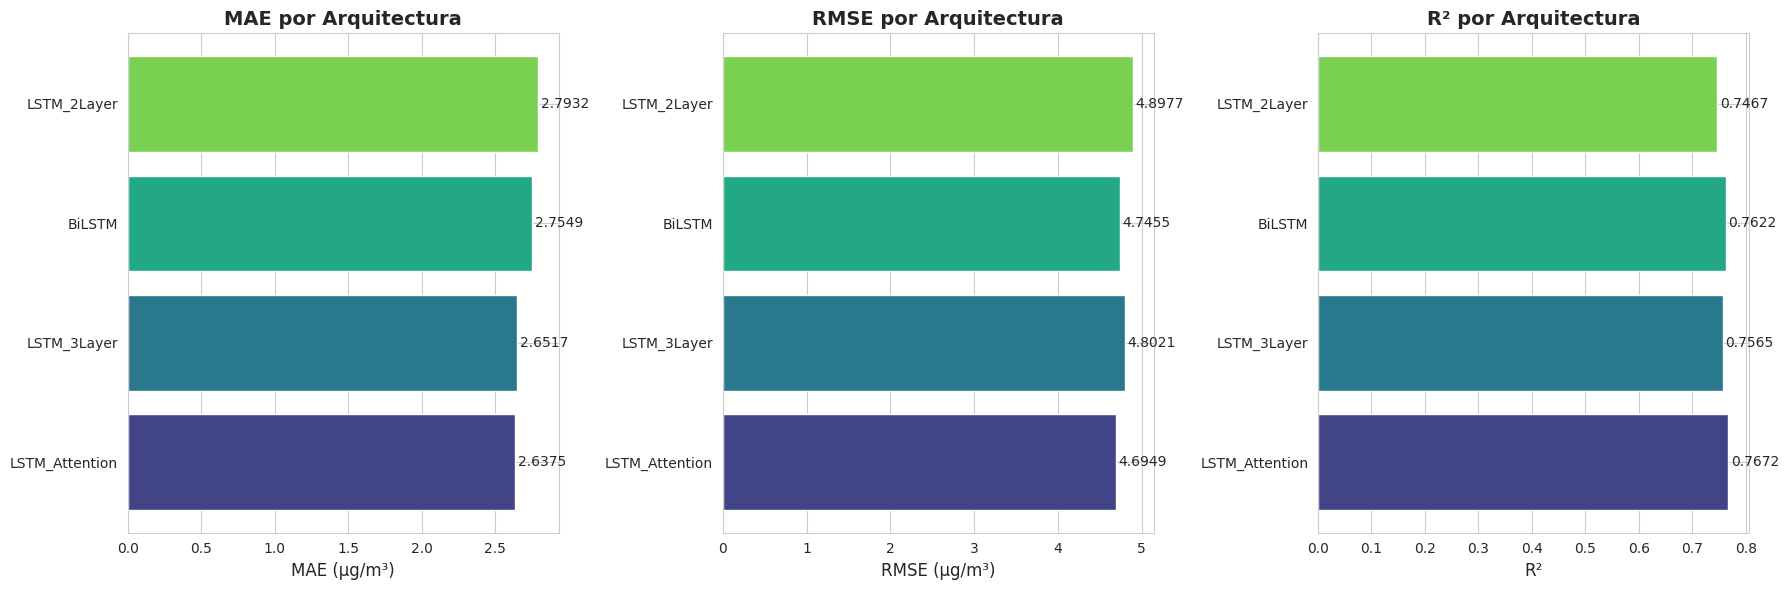

✅ Comparación guardada en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day7_architecture_comparison.png


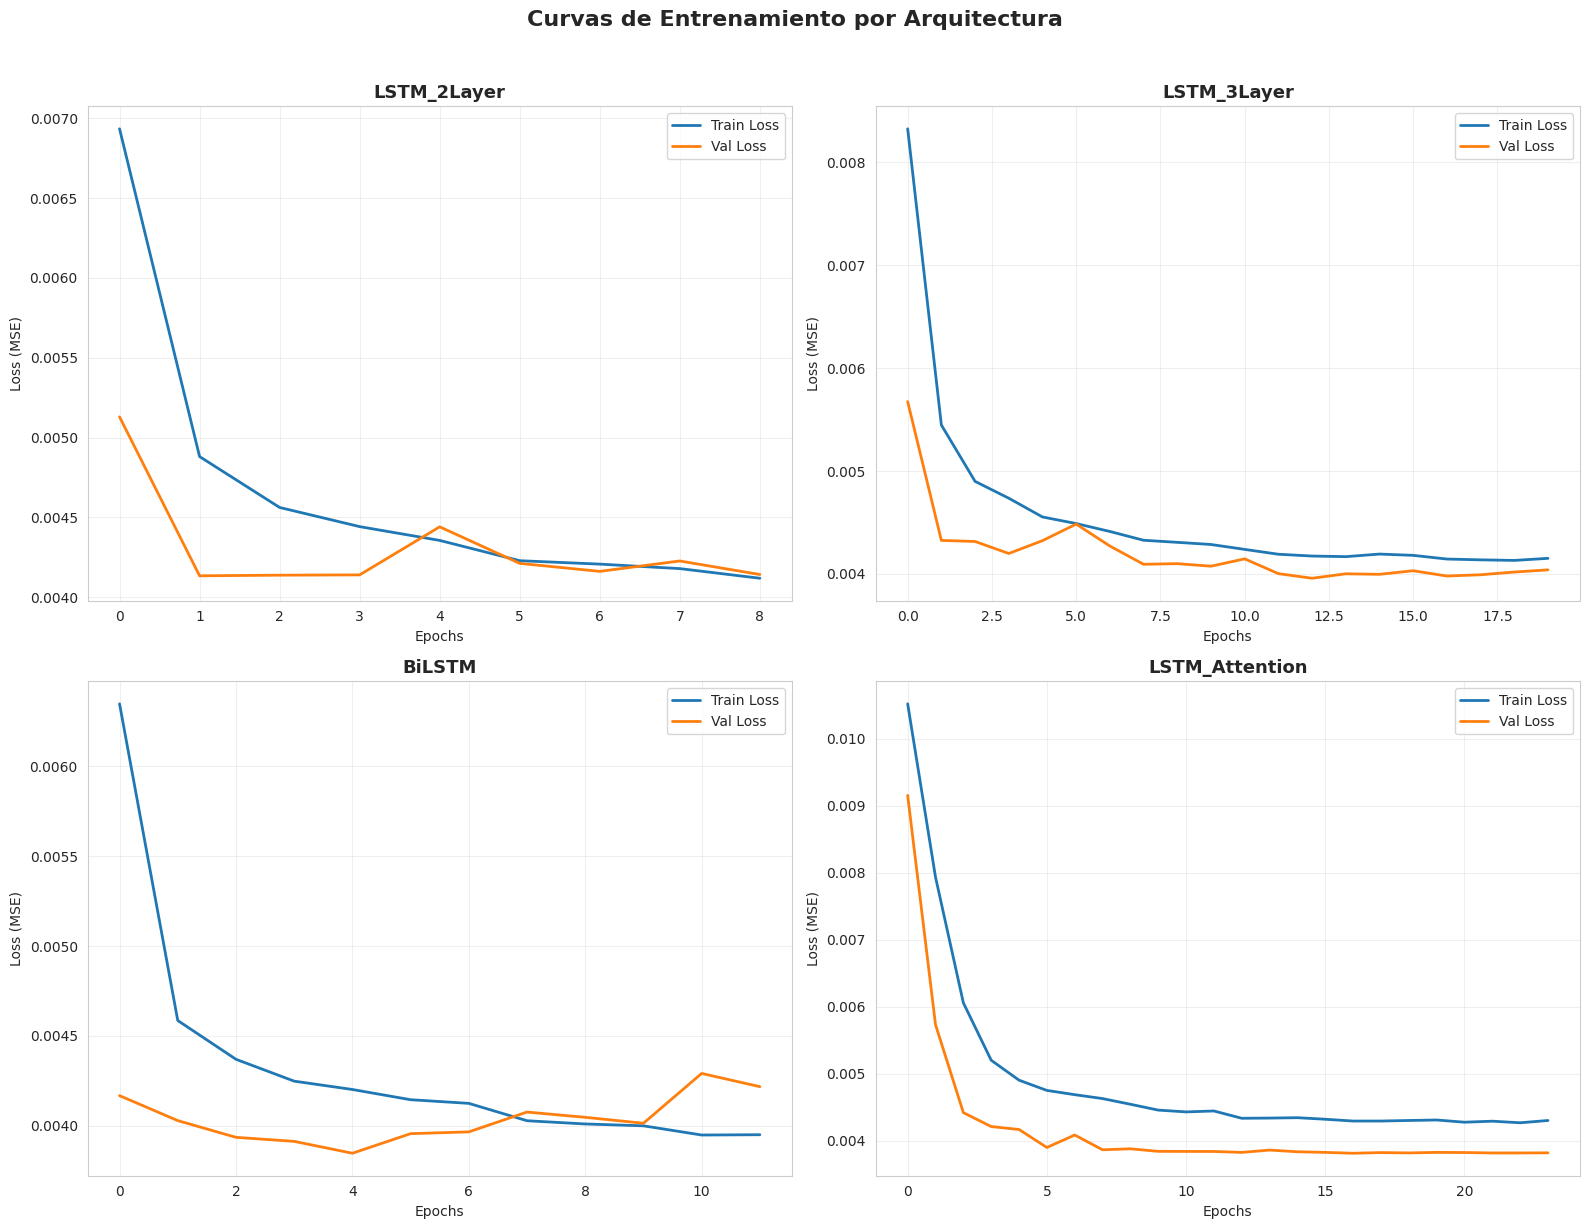

✅ Curvas guardadas en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day7_training_curves.png

🏆 Mejor arquitectura: LSTM_3Layer
   MAE: 2.6517 µg/m³
   Modelo guardado en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/best_model_day7.keras
🎯 Experimentos completados. Usa esta arquitectura para el Día 8.


In [14]:
# ==========================================
# 7. RESULTADOS Y VISUALIZACIONES
# ==========================================
print("\n" + "="*60)
print("📊 COMPARACIÓN DE ARQUITECTURAS")
print("="*60)

results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS_CSV, index=False)
print(f"\n✅ Resultados guardados en: {RESULTS_CSV}")

sorted_df = results_df.sort_values('test_mae_real')
print("\n🏆 Ranking de arquitecturas:")
print(sorted_df[['architecture', 'test_mae_real', 'test_rmse_real', 'test_r2_real',
                  'n_params', 'best_epoch', 'training_time_sec']].to_string(index=False))

# --- Gráfico 1: Barras comparativas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# MAE
ax = axes[0]
colors = sns.color_palette('viridis', len(sorted_df))
bars = ax.barh(sorted_df['architecture'], sorted_df['test_mae_real'], color=colors)
ax.set_xlabel('MAE (µg/m³)', fontsize=12)
ax.set_title('MAE por Arquitectura', fontsize=14, fontweight='bold')
for bar, val in zip(bars, sorted_df['test_mae_real']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2., f'{val:.4f}',
            ha='left', va='center', fontsize=10)

# RMSE
ax = axes[1]
bars = ax.barh(sorted_df['architecture'], sorted_df['test_rmse_real'], color=colors)
ax.set_xlabel('RMSE (µg/m³)', fontsize=12)
ax.set_title('RMSE por Arquitectura', fontsize=14, fontweight='bold')
for bar, val in zip(bars, sorted_df['test_rmse_real']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2., f'{val:.4f}',
            ha='left', va='center', fontsize=10)

# R²
ax = axes[2]
bars = ax.barh(sorted_df['architecture'], sorted_df['test_r2_real'], color=colors)
ax.set_xlabel('R²', fontsize=12)
ax.set_title('R² por Arquitectura', fontsize=14, fontweight='bold')
for bar, val in zip(bars, sorted_df['test_r2_real']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2., f'{val:.4f}',
            ha='left', va='center', fontsize=10)

plt.tight_layout()
comparison_path = os.path.join(RESULTS_DIR, "day7_architecture_comparison.png")
plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Comparación guardada en: {comparison_path}")

# --- Gráfico 2: Curvas de entrenamiento ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, (arch_name, hist) in enumerate(all_histories.items()):
    ax = axes[idx // 2][idx % 2]
    ax.plot(hist['loss'], label='Train Loss', linewidth=2)
    ax.plot(hist['val_loss'], label='Val Loss', linewidth=2)
    ax.set_title(f'{arch_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss (MSE)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Entrenamiento por Arquitectura', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
curves_path = os.path.join(RESULTS_DIR, "day7_training_curves.png")
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Curvas guardadas en: {curves_path}")


print(f"\n🏆 Mejor arquitectura: {best_arch_name}")
print(f"   MAE: {best_mae:.4f} µg/m³")
print(f"   Modelo guardado en: {BEST_MODEL_PATH}")
print("🎯 Experimentos completados. Usa esta arquitectura para el Día 8.")
